In [1]:
# ============================================================
# K-Means Problem: Brute Force, Approximation, Heuristic
# Authors: Abhishek Tiwari, Anish Mukherjee
# ============================================================

In [2]:
import numpy as np
import itertools
import time
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import pandas as pd

In [3]:
# ------------------------------------------------------------
# Utility Functions
# ------------------------------------------------------------
def sse(X, labels, centers):
    """Compute Sum of Squared Errors."""
    total = 0.0
    for i, x in enumerate(X):
        total += np.linalg.norm(x - centers[labels[i]])**2
    return total


def plot_clusters(X, labels, centers, title, filename, show=True):
    """Visualize clustering result (only for 2D)."""
    if X.shape[1] != 2:
        return
    plt.figure(figsize=(5, 4))
    plt.scatter(X[:, 0], X[:, 1], c=labels, s=40, cmap='viridis')
    plt.scatter(centers[:, 0], centers[:, 1], c='red', marker='*', s=200, label='Centroids')
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.savefig(filename, dpi=300)
    if show:
        plt.show()
    plt.close()

In [4]:
# ------------------------------------------------------------
# Brute Force Algorithm (Exact) – Exponential Time
# ------------------------------------------------------------
def brute_force_kmeans(X, k):
    """
    Try all possible cluster assignments to find optimal SSE.
    Only feasible for very small n (<= 10–12).
    """
    n = len(X)
    best_cost = float('inf')
    best_labels = None
    best_centers = None

    for assignment in itertools.product(range(k), repeat=n):
        centers = []
        cost = 0.0
        for cluster in range(k):
            members = X[np.array(assignment) == cluster]
            if len(members) == 0:
                centers.append(np.zeros(X.shape[1]))
                continue
            centroid = np.mean(members, axis=0)
            centers.append(centroid)
            cost += np.sum(np.linalg.norm(members - centroid, axis=1)**2)

        if cost < best_cost:
            best_cost = cost
            best_labels = np.array(assignment)
            best_centers = np.array(centers)
    return best_labels, best_centers, best_cost


In [5]:
# ------------------------------------------------------------
# Approximation Algorithm (k-means++)
# ------------------------------------------------------------
def approx_kmeans(X, k):
    """
    Run k-means++ (using scikit-learn implementation).
    Expected O(log k) approximation factor.
    """
    start = time.time()
    km = KMeans(n_clusters=k, init='k-means++', n_init=10, max_iter=300, random_state=0)
    km.fit(X)
    end = time.time()
    return km.labels_, km.cluster_centers_, km.inertia_, end - start


In [6]:
# ------------------------------------------------------------
# Heuristic Algorithm (Lloyd’s with random restarts)
# ------------------------------------------------------------
def heuristic_kmeans(X, k, n_restarts=20):
    best_cost = float('inf')
    best_labels, best_centers = None, None
    total_time = 0.0

    for seed in range(n_restarts):
        start = time.time()
        km = KMeans(n_clusters=k, init='random', n_init=10, max_iter=300, random_state=None)
        km.fit(X)
        end = time.time()
        cost = km.inertia_
        if cost < best_cost:
            best_cost = cost
            best_labels, best_centers = km.labels_, km.cluster_centers_
        total_time += (end - start)

    avg_time = total_time / n_restarts
    return best_labels, best_centers, best_cost, avg_time


In [7]:
# ------------------------------------------------------------
# Experiment Function
# ------------------------------------------------------------
def run_experiments(show_plots=True):
    results = []
    sizes = [10, 20, 50, 200, 1000]
    k = 3
    dim = 2

    for n in sizes:
        print(f"\nRunning for n = {n}")
        X, _ = make_blobs(n_samples=n, centers=k, n_features=dim, cluster_std=1.0, random_state=42)

        # Brute Force only for small n
        if n <= 12:
            start = time.time()
            labels_bf, centers_bf, cost_bf = brute_force_kmeans(X, k)
            time_bf = time.time() - start
            plot_clusters(X, labels_bf, centers_bf, f"Brute Force (n={n})", f"bf_{n}.png", show=show_plots)
        else:
            labels_bf, centers_bf, cost_bf, time_bf = [None]*4

        # Approximation (k-means++)
        labels_app, centers_app, cost_app, time_app = approx_kmeans(X, k)
        plot_clusters(X, labels_app, centers_app, f"k-means++ (n={n})", f"app_{n}.png", show=show_plots)

        # Heuristic (Lloyd’s)
        labels_heu, centers_heu, cost_heu, time_heu = heuristic_kmeans(X, k, n_restarts=10)
        plot_clusters(X, labels_heu, centers_heu, f"Lloyd's Heuristic (n={n})", f"heu_{n}.png", show=show_plots)

        results.append({
            'n': n,
            'bf_cost': cost_bf,
            'app_cost': cost_app,
            'heu_cost': cost_heu,
            'bf_time': time_bf,
            'app_time': time_app,
            'heu_time': time_heu
        })

    return results

In [8]:
# ------------------------------------------------------------
# Visualization of Results
# ------------------------------------------------------------
def plot_results(results, show=True):
    
    df = pd.DataFrame(results)
    print(df.head())
    ns = [r['n'] for r in results]
    print("ns = ",ns)
    # ----- SSE Plot -----
    plt.figure(figsize=(6, 4))
    plt.plot(ns, [r['app_cost'] for r in results], 'o-', label='k-means++')
    plt.plot(ns, [r['heu_cost'] for r in results], 's--', label='Heuristic')

    # # Filter only brute force results that exist
    # bf_points = [(r['n'], r['bf_cost']) for r in results if r['bf_cost'] is not None]
    # if bf_points:
    #     bf_ns, bf_costs = zip(*bf_points)
    #     plt.plot(bf_ns, bf_costs, 'x-.', label='Brute Force')

    plt.xlabel('Number of Points (n)')
    plt.ylabel('SSE (Cost)')
    plt.title('SSE vs Dataset Size')
    plt.legend()
    plt.tight_layout()
    plt.savefig('cost_vs_n.png', dpi=300)
    if show:
        plt.show()
    plt.close()

    # ----- Runtime Plot -----
    plt.figure(figsize=(6, 4))
    plt.plot(ns, [r['app_time'] for r in results], 'o-', label='k-means++')
    plt.plot(ns, [r['heu_time'] for r in results], 's--', label='Heuristic')

    # bf_points_time = [(r['n'], r['bf_time']) for r in results if r['bf_time'] is not None]
    # if bf_points_time:
    #     bf_ns, bf_times = zip(*bf_points_time)
    #     plt.plot(bf_ns, bf_times, 'x-.', label='Brute Force')

    plt.xlabel('Number of Points (n)')
    plt.ylabel('Runtime (seconds)')
    plt.title('Runtime vs Dataset Size')
    plt.legend()
    plt.tight_layout()
    plt.savefig('time_vs_n.png', dpi=300)
    if show:
        plt.show()
    plt.close()


Running for n = 10


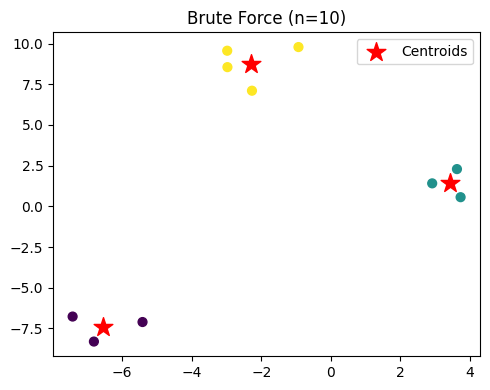

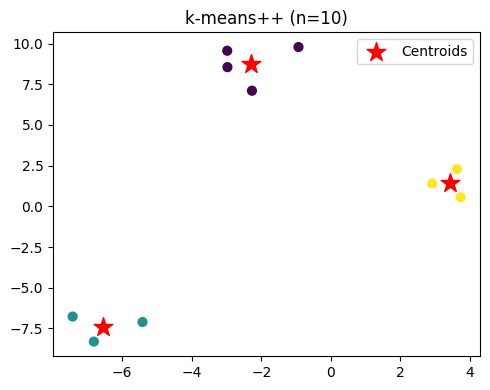

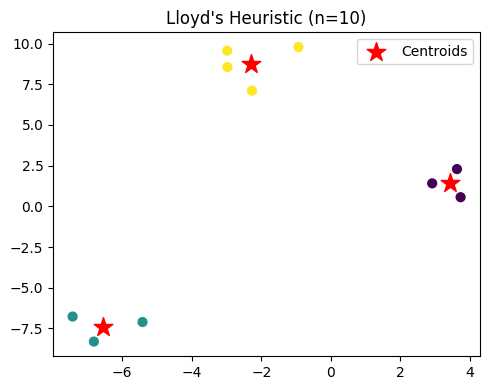


Running for n = 20


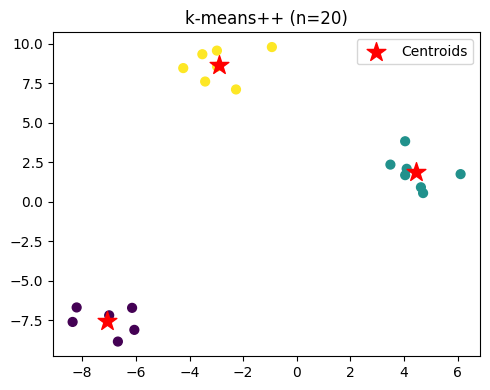

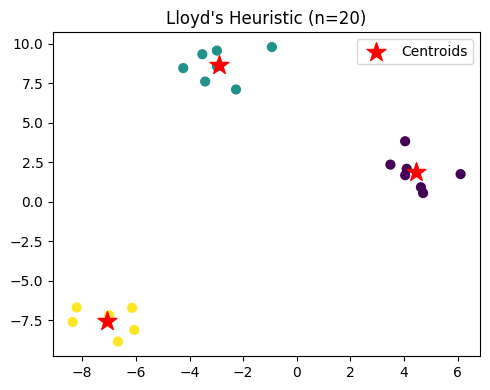


Running for n = 50


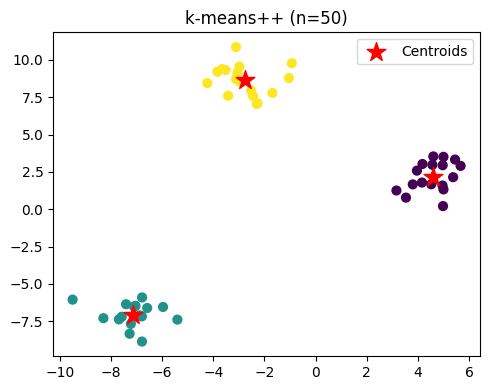

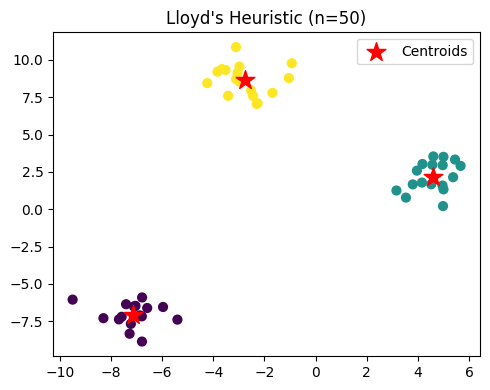


Running for n = 200


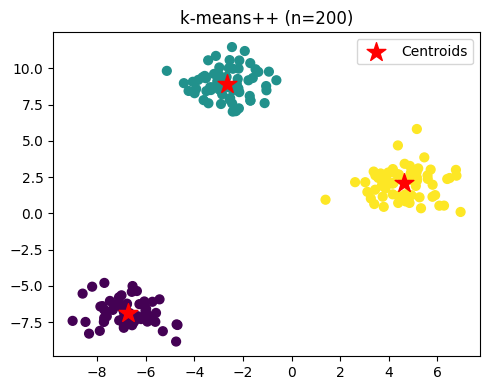

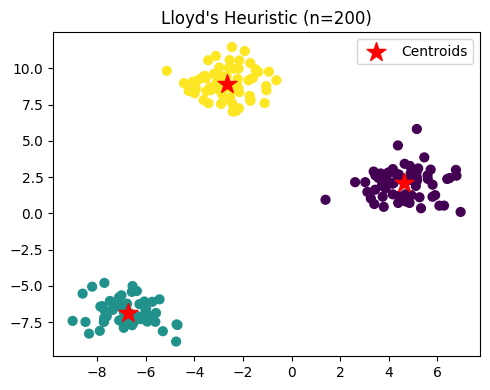


Running for n = 1000


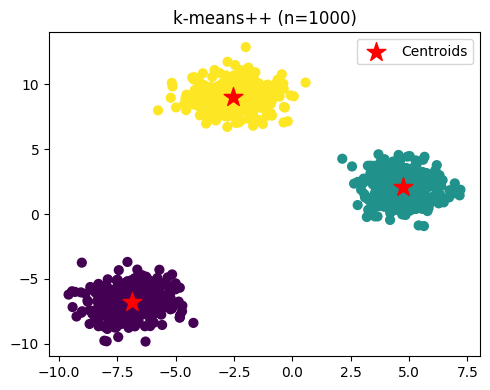

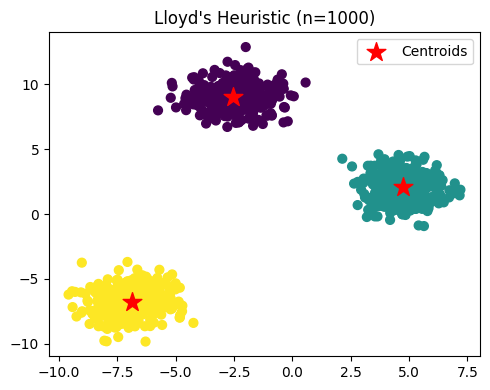

      n    bf_cost     app_cost     heu_cost   bf_time  app_time  heu_time
0    10  12.577459    12.577459    12.577459  4.069254  0.137171  0.015677
1    20        NaN    32.431894    32.431894       NaN  0.018358  0.013034
2    50        NaN    76.700483    76.700483       NaN  0.021001  0.011299
3   200        NaN   364.473321   364.473321       NaN  0.015989  0.013790
4  1000        NaN  1950.881499  1950.881499       NaN  0.025001  0.020900
ns =  [10, 20, 50, 200, 1000]


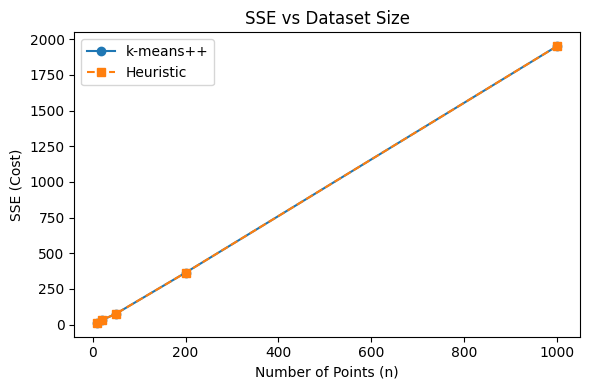

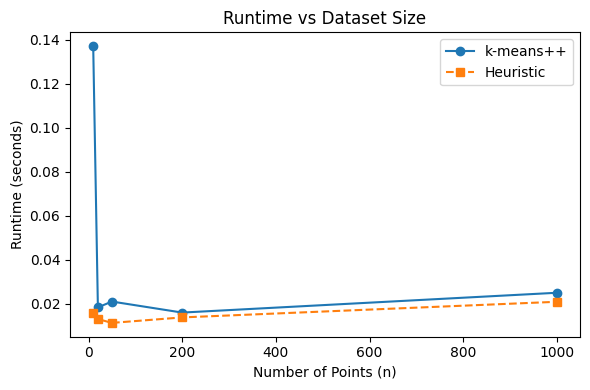


=== Summary ===
{'n': 10, 'bf_cost': 12.577458547026467, 'app_cost': 12.577458547026469, 'heu_cost': 12.577458547026469, 'bf_time': 4.069253921508789, 'app_time': 0.13717079162597656, 'heu_time': 0.01567714214324951}
{'n': 20, 'bf_cost': None, 'app_cost': 32.43189392504041, 'heu_cost': 32.43189392504041, 'bf_time': None, 'app_time': 0.018358230590820312, 'heu_time': 0.01303408145904541}
{'n': 50, 'bf_cost': None, 'app_cost': 76.70048331852811, 'heu_cost': 76.70048331852811, 'bf_time': None, 'app_time': 0.021001338958740234, 'heu_time': 0.011298751831054688}
{'n': 200, 'bf_cost': None, 'app_cost': 364.4733211131726, 'heu_cost': 364.4733211131726, 'bf_time': None, 'app_time': 0.015988826751708984, 'heu_time': 0.013789892196655273}
{'n': 1000, 'bf_cost': None, 'app_cost': 1950.8814994726636, 'heu_cost': 1950.881499472663, 'bf_time': None, 'app_time': 0.02500128746032715, 'heu_time': 0.02090017795562744}


In [9]:
if __name__ == "__main__":
    results = run_experiments(show_plots=True)
    plot_results(results, show=True)
    print("\n=== Summary ===")
    for r in results:
        print(r)

      n    bf_cost     app_cost     heu_cost   bf_time  app_time  heu_time
0    10  12.577459    12.577459    12.577459  4.069254  0.137171  0.015677
1    20        NaN    32.431894    32.431894       NaN  0.018358  0.013034
2    50        NaN    76.700483    76.700483       NaN  0.021001  0.011299
3   200        NaN   364.473321   364.473321       NaN  0.015989  0.013790
4  1000        NaN  1950.881499  1950.881499       NaN  0.025001  0.020900
ns =  [10, 20, 50, 200, 1000]


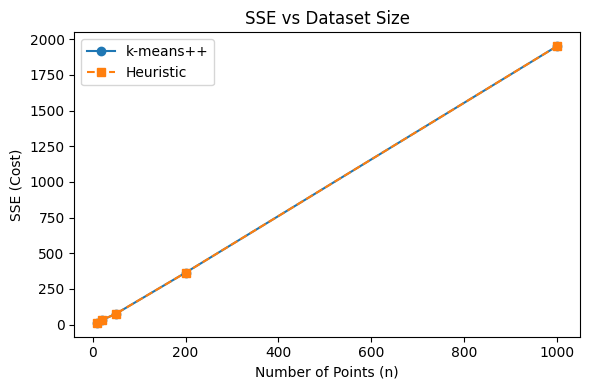

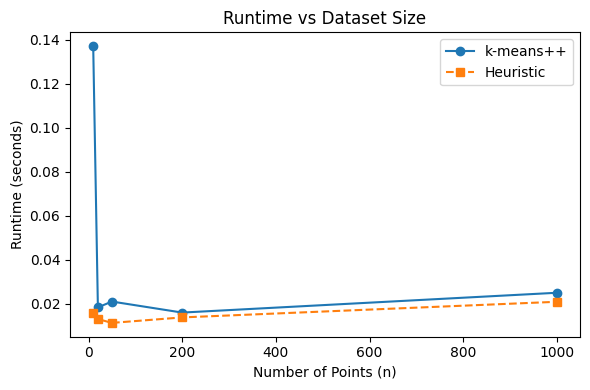

In [10]:
plot_results(results, show=True)